# Titanic Project, Solution Achieves Top 16% on Public Leaderboard:
https://www.kaggle.com/competitions/titanic

## Import Packages and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from pathlib import Path

In [2]:
data_dir = Path("../Data")

train = pd.read_csv(data_dir / "train.csv")
train["Dataset"] = "Train"

test = pd.read_csv(data_dir / "test.csv")
test["Dataset"] = "Test"

dfs = [train, test]

for df in dfs:
    df["ParCh"] = df["Parch"]
    df = df.drop(["Parch"], axis=1)

## Basic Exploration

In [3]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Dataset', 'ParCh'],
      dtype='object')

In [4]:
train["Survived"].isna().sum()

np.int64(0)

In [5]:
train["Survived"].mean()

np.float64(0.3838383838383838)

In [6]:
# Unbalanced but not critically so, look at survived by class and gender (most important features at first glance)

train.groupby(["Sex", "Pclass"]).agg({
    "Survived": "mean"
    })

Survived
Sex    Pclass          
female 1       0.968085
       2       0.921053
       3       0.500000
male   1       0.368852
       2       0.157407
       3       0.135447

In [7]:
# Very good model here already, use this as base

m1 = test["Sex"] == "female"
m2 = test["Pclass"].isin([1, 2])
m3 = test["Pclass"] == 1

In [8]:
random.seed(99)

basic_preds = np.where((test["Sex"] == "female") & (test["Pclass"].isin([1, 2])), 1, 
         np.where((test["Sex"] == "female") & (test["Pclass"].isin([3])),random.randint(0, 1), 
                  np.where((test["Sex"] == "male") & (test["Pclass"].isin([1])), 1 if random.random() < 0.33 else 0, 0)))

In [9]:
# The below gets ~top 59% on kaggle, bad but a very decent baseline to improve upon. Also note there's randomness involved and this seems a particularly good seed!

basic_sub = pd.concat([test["PassengerId"], pd.Series(basic_preds)], axis=1)
basic_sub.columns = ["PassengerId", "Survived"]

submissions_dir = Path("../Submissions")
basic_sub.to_csv(submissions_dir / "baseline_model.csv", index=False)

## Null Handling and Feature Engineering

In [10]:
for df in dfs:
    print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Dataset          0
ParCh            0
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Dataset          0
ParCh            0
dtype: int64


In [11]:
# Not many nulls here whatsoever. Cabin and Age the big ones at ~77% and ~20% missing respectively. Firstly make binary flags of missing age and missing cabin and look for patterns.

for df in dfs:
    df["AgeMissingFlag"] = (df["Age"].isna()).astype(int)
    df["CabinMissingFlag"] = (df["Cabin"].isna()).astype(int)

In [12]:
# Heavily missing columns by Pclass

train.groupby("Pclass").agg({
    "AgeMissingFlag": "mean",
    "CabinMissingFlag": "mean"
})

,AgeMissingFlag,CabinMissingFlag
Pclass,,
1,0.138889,0.185185
2,0.059783,0.913043
3,0.276986,0.975560


In [13]:
# Cabin missing is heavily correlated with class. 
# Could mean 2nd and third class passengers typically don't have a private cabin. Which honestly makes sense.
# Age missing is weakly correlated with class, particularly third. Lets drop that binary flag.

# Check state of Cabin variable

train["Cabin"][~train["Cabin"].isna()].head(20)

1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33
54            B30
55            C52
61            B28
62            C83
66            F33
75          F G73
88    C23 C25 C27
92            E31
96             A5
97        D10 D12
Name: Cabin, dtype: object

Make Cabin variables

In [14]:
# You can have multiple cabins, the letters also presumably mean something too. Lets make NCabins, CabinNumber, and CabinDeck (letter), also CabinGroupSize

for df in dfs:
    df["NCabins"] = df["Cabin"].fillna("").apply(lambda x: len(x.split()) if x != "" else 0)


In [15]:
def extract_letters(cabin):
    if pd.isna(cabin):
        return "Z"
    
    letters = {x[0] for x in cabin.split() if x and x[0] != "F"}
    
    return "".join(sorted(letters)) if letters else "Z"

for df in dfs:
    df["CabinDeck"] = df["Cabin"].apply(extract_letters)


In [16]:
for df in dfs:
    df["CabinDeckAdj"] = df["CabinDeck"].replace(["A", "B", "C", "T"], "ABCT").replace(["D", "E"], "DE").replace(["G"], "Z")

In [17]:
train["CabinDeck"].value_counts()

CabinDeck
Z    696
C     59
B     47
E     33
D     33
A     15
G      7
T      1
Name: count, dtype: int64

In [18]:
train["CabinDeckAdj"].value_counts()

CabinDeckAdj
Z       703
ABCT    122
DE       66
Name: count, dtype: int64

In [19]:
for df in dfs:
    cabin_gb = df.groupby("Cabin").agg({
        "PassengerId": "count"
    }).reset_index()
    cabin_gb.columns = ["Cabin", "CGSize"]

    cabin_dict = dict(zip(cabin_gb["Cabin"], cabin_gb["CGSize"]))

    df["CabinGroupSize"] = df["Cabin"].map(cabin_dict)
    df["CabinGroupSize"] = df["CabinGroupSize"].fillna(0)

    df["PeoplePerCabin"] = df["CabinGroupSize"]/df["NCabins"]
    df["PeoplePerCabin"] = df["PeoplePerCabin"].fillna(0)

    del cabin_gb, cabin_dict

Make Name variables

In [20]:
train["Name"].head(5)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [21]:
for df in dfs:
    df["Surname"] = df["Name"].str.split(",").str[0]
    df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.')

In [22]:
train["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [23]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

title_mapping = {
    "Rev": "RevDr",
    "Dr": "RevDr",
    "Col": "Rare",
    "Mlle": "Miss",
    "Major": "Rare",
    "Ms": "Miss",
    "Lady": "Rare",
    "Sir": "Rare",
    "Mme": "Miss",
    "Don": "Rare",
    "Capt": "Rare",
    "the Countess": "Rare",
    "Jonkheer": "Rare",
    "Dona": "Rare"
}
for df in dfs:
    df["TitleAdj"] = np.where(df["Title"].isin(common_titles), df["Title"], df["Title"].map(title_mapping))
    df = df.drop("Title", axis=1)
    df = df.reset_index(drop=True)

Make Immediate Family GroupSize and Ticket GroupSize, have a good old compare of all created GroupSizes

In [24]:
for df in dfs:
    df["ImmediateFamilyGroupSize"] = df["SibSp"] + df["ParCh"] + 1

In [25]:
comb = pd.concat([train, test], axis=0)

ticket_gb = comb.groupby("Ticket").agg({
    "PassengerId": "count"
}).reset_index()
ticket_gb.columns = ["Ticket", "CGSize"]

ticket_dict = dict(zip(ticket_gb["Ticket"], ticket_gb["CGSize"]))

for df in dfs:
    df["TicketGroupSize"] = df["Ticket"].map(ticket_dict)
    df["TicketGroupSize"] = df["TicketGroupSize"].fillna(0)

del ticket_gb, ticket_dict

In [26]:
m1 = train["Pclass"] == 3
m2 = train["Embarked"] == "S"
m3 = train["TitleAdj"] == "Mr"
m4 = train["TicketGroupSize"] == 1

golden_number = train[m1 & m2 & m3 & m4]["Fare"].median()
print(golden_number)

test.loc[152, "Fare"] = golden_number

7.8958


In [27]:
# Make avg ticket price

for df in dfs:
    df[["Fare", "TicketGroupSize"]][df["Pclass"]==1]

    df["AverageTicketPrice"] = df["Fare"]/df["TicketGroupSize"]

Fill Embarked with Mode

In [28]:
for df in dfs:
    df["Embarked"] = df["Embarked"].fillna("S")

Model Age

In [29]:
age_model_variables = ["Pclass", "Sex", "SibSp", "Fare", "Embarked", "ParCh", "CabinMissingFlag", "NCabins", "CabinDeck", "CabinGroupSize", "PeoplePerCabin",
                       "TitleAdj", "TicketGroupSize", "AverageTicketPrice"]

age_model_train = train[~train["Age"].isna()][age_model_variables].reset_index(drop=True)
age_model_predict = train[train["Age"].isna()][age_model_variables].reset_index(drop=True)
age_model_predict_test = test[test["Age"].isna()][age_model_variables].reset_index(drop=True)

age_y_train = train["Age"][~train["Age"].isna()].reset_index(drop=True)
age_cat_vars = ["Sex", "Embarked", "CabinDeck", "TitleAdj"]
age_model_train[age_cat_vars] = age_model_train[age_cat_vars].astype(str)

In [30]:
best_params = {
    'loss_function': 'RMSE',
    'learning_rate': 0.01,
    'depth': 6,
    'l2_leaf_reg': 5,
    'iterations': 5000
}

best_model = CatBoostRegressor(
    **best_params,
    random_seed=99,
    cat_features=age_cat_vars,
    verbose=False
)

best_model.fit(age_model_train, age_y_train)

age_predictions = best_model.predict(age_model_predict)
age_predictions_test = best_model.predict(age_model_predict_test)

train["AgeAdj"] = train["Age"].copy()
train.loc[train["Age"].isna(), "AgeAdj"] = age_predictions
train["AgeAdj"] = train["AgeAdj"].round(0)
test["AgeAdj"] = test["Age"].copy()
test.loc[test["Age"].isna(), "AgeAdj"] = age_predictions_test
test["AgeAdj"] = test["AgeAdj"].round(0)

In [31]:
for df in dfs:
    df["NoFamFlag"] = (df["ImmediateFamilyGroupSize"]==1).astype(int)
    df["CabinAloneFlag"] = (df["CabinGroupSize"]==1).astype(int)
    df["TicketAloneFlag"] = (df["TicketGroupSize"]==1).astype(int)
    df["MarriedFlag"] = (df["TitleAdj"]=="Mrs").astype(int)
    df["LFare"] = np.where(df["Fare"]>0, np.log(df["Fare"]), 0)

/opt/homebrew/Caskroom/miniforge/base/envs/base_env_py311/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/base_env_py311/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Make Other Features

In [32]:
train["Survived"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [33]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Dataset', 'ParCh',
       'AgeMissingFlag', 'CabinMissingFlag', 'NCabins', 'CabinDeck',
       'CabinDeckAdj', 'CabinGroupSize', 'PeoplePerCabin', 'Surname', 'Title',
       'TitleAdj', 'ImmediateFamilyGroupSize', 'TicketGroupSize',
       'AverageTicketPrice', 'AgeAdj', 'NoFamFlag', 'CabinAloneFlag',
       'TicketAloneFlag', 'MarriedFlag', 'LFare'],
      dtype='object')

<Axes: xlabel='Age', ylabel='Count'>

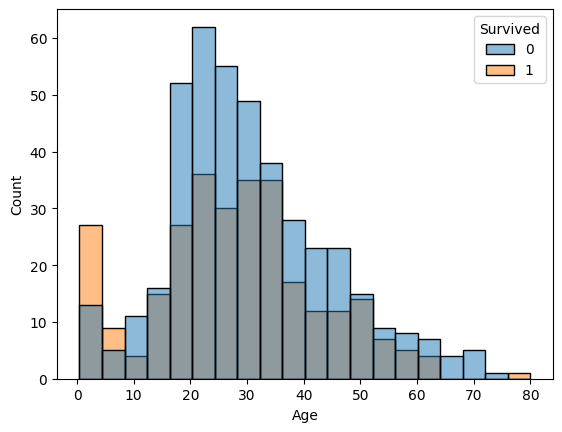

In [34]:
sns.histplot(data=train, x="Age", hue="Survived")

<Axes: xlabel='Fare', ylabel='Count'>

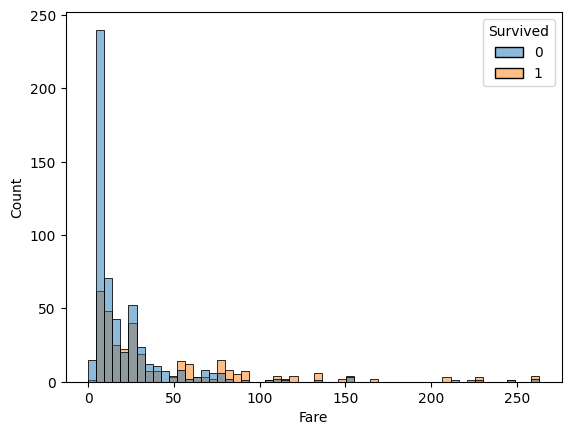

In [35]:
sns.histplot(data=train[train["Fare"]<300], x="Fare", hue="Survived")

In [36]:
train[train["Age"]==5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,TitleAdj,ImmediateFamilyGroupSize,TicketGroupSize,AverageTicketPrice,AgeAdj,NoFamFlag,CabinAloneFlag,TicketAloneFlag,MarriedFlag,LFare
58,59,1,2,"West, Miss. Constance Mirium",female,5.0,1,2,C.A. 34651,27.7500,...,Miss,4,4,6.937500,5.0,0,0,0,0,3.323236
233,234,1,3,"Asplund, Miss. Lillian Gertrud",female,5.0,4,2,347077,31.3875,...,Miss,7,7,4.483929,5.0,0,0,0,0,3.446410
448,449,1,3,"Baclini, Miss. Marie Catherine",female,5.0,2,1,2666,19.2583,...,Miss,4,4,4.814575,5.0,0,0,0,0,2.957942
777,778,1,3,"Emanuel, Miss. Virginia Ethel",female,5.0,0,0,364516,12.4750,...,Miss,1,2,6.237500,5.0,1,0,0,0,2.523727


In [37]:
agebins = [-float("inf"), 5, 13, 17, 30, 55, float("inf")]
agelabs = [1, 2, 3, 4, 5, 6]

for df in dfs:
    df["AgeBand"] = pd.cut(df["AgeAdj"], bins=agebins, labels=agelabs).astype(int)

In [38]:
farelabs = [1, 2, 3, 4, 5]

for df in dfs:
    df["FareBand"] = pd.qcut(df["Fare"], q=5, labels=farelabs).astype(int)

for df in dfs:
    df["AverageTicketPriceBand"] = pd.qcut(df["AverageTicketPrice"], q=5, labels=farelabs).astype(int)

## Preprocessing

In [39]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Dataset', 'ParCh',
       'AgeMissingFlag', 'CabinMissingFlag', 'NCabins', 'CabinDeck',
       'CabinDeckAdj', 'CabinGroupSize', 'PeoplePerCabin', 'Surname', 'Title',
       'TitleAdj', 'ImmediateFamilyGroupSize', 'TicketGroupSize',
       'AverageTicketPrice', 'AgeAdj', 'NoFamFlag', 'CabinAloneFlag',
       'TicketAloneFlag', 'MarriedFlag', 'LFare', 'AgeBand', 'FareBand',
       'AverageTicketPriceBand'],
      dtype='object')

In [40]:
oh_targs = ["Sex", "Embarked", "CabinDeckAdj", "TitleAdj"]
drops = ["Name", "Age", "Ticket", "Fare", "Cabin", "Dataset", "Parch", "CabinDeck", "Surname", "Title", "AgeAdj", "LFare", "AverageTicketPrice"]
dont_use = ["PassengerId", "Survived"]

X_train = train.drop(drops, axis=1)[[i for i in train.columns if i not in dont_use + drops]].reset_index(drop=True)
X_test = test.drop(drops, axis=1)[[i for i in test.columns if i not in dont_use + drops]].reset_index(drop=True)

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

y_train = train["Survived"]

In [41]:
def one_hot_replace(df, cols):
    base_df = df.drop(columns=cols)
    dummies = pd.get_dummies(df[cols]).astype(int)
    return pd.concat([base_df, dummies], axis=1)

X_train_oh = one_hot_replace(X_train, oh_targs)
X_test_oh  = one_hot_replace(X_test, oh_targs)

t_dfs = [X_train_oh, X_test_oh]

X_train_oh = X_train_oh.drop(["TitleAdj_Rare", "CabinAloneFlag", "CabinDeckAdj_ABCT", "TitleAdj_RevDr", "NoFamFlag", "ParCh"], axis=1)
X_test_oh = X_test_oh.drop(["TitleAdj_Rare", "CabinAloneFlag", "CabinDeckAdj_ABCT", "TitleAdj_RevDr", "NoFamFlag", "ParCh"], axis=1)

In [42]:
X_train_oh.columns

Index(['Pclass', 'SibSp', 'AgeMissingFlag', 'CabinMissingFlag', 'NCabins',
       'CabinGroupSize', 'PeoplePerCabin', 'ImmediateFamilyGroupSize',
       'TicketGroupSize', 'TicketAloneFlag', 'MarriedFlag', 'AgeBand',
       'FareBand', 'AverageTicketPriceBand', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'CabinDeckAdj_DE',
       'CabinDeckAdj_Z', 'TitleAdj_Master', 'TitleAdj_Miss', 'TitleAdj_Mr',
       'TitleAdj_Mrs'],
      dtype='object')

In [43]:
run_tune = False

rf = RandomForestClassifier(
    random_state=99,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": randint(100, 600),
    "max_depth": [None] + list(range(5, 31, 5)),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,        
    cv=5,           
    scoring="accuracy",
    verbose=2,
    random_state=99,
    n_jobs=-1
)

if run_tune:
    rf_search.fit(X_train_oh, y_train)

    best_rf = rf_search.best_estimator_

    print("Best CV score:", rf_search.best_score_)
    print("Best parameters:")
    print(rf_search.best_params_)

In [44]:
run_tune = False

xgb = XGBClassifier(
    objective="binary:logistic", 
    eval_metric="logloss",
    random_state=99,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": randint(300, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.5),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.7),
    "reg_alpha": uniform(0, 1.0),
    "reg_lambda": uniform(0.5, 1.5)
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=100,     
    cv=5,           
    scoring="accuracy",
    verbose=2,
    random_state=99,
    n_jobs=-1
)

if run_tune:

    xgb_search.fit(X_train_oh, y_train)

    best_xgb = xgb_search.best_estimator_

    print("Best CV score:", xgb_search.best_score_)
    print("Best parameters:")
    print(xgb_search.best_params_)

In [45]:
best_rf_params = {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 11, 'n_estimators': 330}
best_rf = RandomForestClassifier(**best_rf_params, random_state=99)
best_rf.fit(X_train_oh, y_train)
preds = best_rf.predict(X_test_oh)

In [46]:
rf_sub = pd.concat([test["PassengerId"], pd.Series(preds)], axis=1)
rf_sub.columns = ["PassengerId", "Survived"]
rf_sub.to_csv(Path("../Submissions") / "rf2.csv", index=False)

In [47]:
best_xgb_params = {'colsample_bytree': 0.8557445427896969, 'gamma': 0.5635312672635533, 'learning_rate': 0.46157552933831314, 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 337, 'reg_alpha': 0.6080878495418852, 'reg_lambda': 1.4549664824334239, 'subsample': 0.8219262434168902}
best_xgb = XGBClassifier(**best_xgb_params, random_state=99)
best_xgb.fit(X_train_oh, y_train)
preds = best_xgb.predict(X_test_oh)

In [48]:
xgb_sub = pd.concat([test["PassengerId"], pd.Series(preds)], axis=1)
xgb_sub.columns = ["PassengerId", "Survived"]
xgb_sub.to_csv(Path("../Submissions") / "xgb.csv", index=False)